<a href="https://colab.research.google.com/github/MhiyaJ/My-GIS-Stuff/blob/main/*PS1-%20School%20Districts%20w/%20Municipality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
#!pip install geopandas #==1.0.1
#!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [2]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [3]:
#!python --version
gpd.__version__

'1.1.4'

**Hypothesis**: Limited access to affordable after-school programs contributes to increased social disengagement and delinquent behavior among students living in urban areas.

**Project Description:** Identifying the availability and accessibility of after school programs in low income areas and examining their relationship to youth social disengagement and delinquent behaviors.  

*Variables:* After school programs, economically disadvantaged youth population, delinquent/disengaged behavior, household income

Unified School Districts in NJ - includes and operates primary, secondary and high school as one district

Census data used to create boundaries for unified school districts.

NJ Office of GIS used Census data to establish unified school district boundaries in two areas, on and near military bases, were edited to reflect special arrangements made for students residing in base housing.

NJDOE used set of grades, based on financial responsibility, to assign the data for each child to exactly one school district, except for districts covering Joint Base McGuire-Dix-Lakehurst in Burlington County.

In [4]:
#NJ Office of GIS (Jan. 14, 2022), School Districts - Unified for NJ, 3424
#https://njogis-newjersey.opendata.arcgis.com/datasets/newjersey::school-districts-unified-for-nj-3424/about)
#unified school district shown in mp below was made with municipalities in mind
! wget -q -O nj-schools.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/School_Districts___Unified_7341673536716239500.zip

zip_ref = zipfile.ZipFile('nj-schools.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njSch=gpd.read_file('School_Districts_Unified.shp') #labeled shapefile njSch

<Axes: >

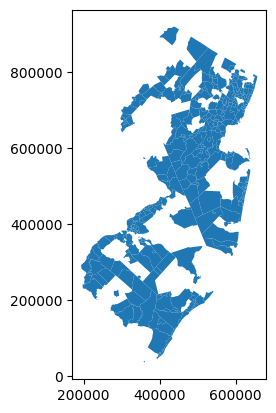

In [5]:
njSch.plot()

In [6]:
njSch.dtypes #School District Headings

,0
NJDOE_ID_U,object
DIST_NAME,object
UNSDLEA,object
SD_TYPE,object
GEOID,object
geometry,geometry


In [7]:
#change column names
njSch.rename(columns={'DIST_NAME' : 'District'}, inplace=True)

In [8]:
#make all upper case
njSch['District'] = njSch['District'].str.upper()

In [9]:
njSch.columns

Index(['NJDOE_ID_U', 'District', 'UNSDLEA', 'SD_TYPE', 'GEOID', 'geometry'], dtype='object')

In [10]:
#Googled - Splitting columns into 2, Option 3: Split text and numbers using Regular Expressions
njSch["NJDOE_ID_U"] = njSch["NJDOE_ID_U"].astype(str)
njSch[["CountyCode", "DistrictCode"]] = njSch["NJDOE_ID_U"].str.extract(r"(\d{2}).*(\d{4})")

In [11]:
#new columns, DistrictCode and CountyCode, with County Code only including Camden County
njSch[njSch['CountyCode'] == '07'][['DistrictCode', 'CountyCode', 'District', 'GEOID']]

,DistrictCode,CountyCode,District,GEOID
34,5820,07,WINSLOW TOWNSHIP SCHOOL DISTRICT,3418060
41,0150,07,AUDUBON PUBLIC SCHOOL DISTRICT,3401050
43,0940,07,COLLINGSWOOD PUBLIC SCHOOL DISTRICT,3403420
50,1880,07,HADDON HEIGHTS SCHOOL DISTRICT,3406330
51,2130,07,HI NELLA,3407080
52,3770,07,OAKLYN PUBLIC SCHOOL DISTRICT,3411940
53,0800,07,CHERRY HILL SCHOOL DISTRICT,3403000
54,1900,07,HADDONFIELD SCHOOL DISTRICT,3406390
58,4110,07,PINE HILL SCHOOL DISTRICT,3412990
59,1890,07,HADDON TOWNSHIP SCHOOL DISTRICT,3406360


In [12]:
DisXls=pd.read_excel ('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Economically%20Disadvantage%20Youth.xlsx', header = 3)

In [13]:
DisXls.dtypes

,0
CountyCode,int64
CountyName,object
DistrictCode,int64
Municpality,object
DistrictName,object
SchoolYear,object
Female,object
Male,object
Non-Binary/Undesignated Gender,object
Economically Disadvantaged Students,object


In [14]:
DisXls1=DisXls[DisXls['SchoolYear'] =='2024-25'][['CountyName','DistrictCode','DistrictName','Economically Disadvantaged Students']]
DisXls1.rename(columns={'DistrictName' : 'District'}, inplace=True)
DisXls1['District'] = DisXls1['District'].str.upper()
DisXls1

,CountyName,DistrictCode,District,Economically Disadvantaged Students
4,Camden,150,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%
9,Camden,190,BARRINGTON SCHOOL DISTRICT,34.1%
14,Camden,260,BELLMAWR PUBLIC SCHOOL DISTRICT,57.8%
19,Camden,330,BERLIN BOROUGH SCHOOL DISTRICT,25.2%
24,Camden,340,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%
29,Camden,390,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,44.9%
34,Camden,580,BROOKLAWN PUBLIC SCHOOL DISTRICT,70.7%
39,Camden,680,CAMDEN CITY SCHOOL DISTRICT,88.5%
44,Camden,700,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,56.1%
49,Camden,800,CHERRY HILL SCHOOL DISTRICT,23.2%


In [15]:
njSch['DistrictCode'] = njSch['DistrictCode'].astype(str)
DisXls1['DistrictCode'] = DisXls1['DistrictCode'].astype(str).str.zfill(4) # Ensure 4 digits with leading zeros

njSch_filtered = njSch[njSch['CountyCode'] == '07'].copy() # Use .copy() to avoid SettingWithCopyWarning

a1 = pd.merge(njSch_filtered, DisXls1, left_on='DistrictCode', right_on='DistrictCode', how='outer', indicator=True)
a1

,NJDOE_ID_U,District_x,UNSDLEA,SD_TYPE,GEOID,geometry,CountyCode,DistrictCode,CountyName,District_y,Economically Disadvantaged Students,_merge
0,07-0150,AUDUBON PUBLIC SCHOOL DISTRICT,01050,U,3401050,"POLYGON ((333599.519 389532.256, 334908.018 38...",07,0150,Camden,AUDUBON PUBLIC SCHOOL DISTRICT,24.5%,both
1,07-0190,BARRINGTON SCHOOL DISTRICT,01170,U,3401170,"POLYGON ((341374.86 382055.06, 341383.46 38191...",07,0190,Camden,BARRINGTON SCHOOL DISTRICT,34.1%,both
2,NaN,NaN,NaN,NaN,NaN,None,NaN,0260,Camden,BELLMAWR PUBLIC SCHOOL DISTRICT,57.8%,right_only
3,NaN,NaN,NaN,NaN,NaN,None,NaN,0330,Camden,BERLIN BOROUGH SCHOOL DISTRICT,25.2%,right_only
4,07-0340,BERLIN TOWNSHIP SCHOOL DISTRICT,01620,U,3401620,"POLYGON ((374626.851 357935.944, 375096.547 35...",07,0340,Camden,BERLIN TOWNSHIP SCHOOL DISTRICT,53.3%,both
5,NaN,NaN,NaN,NaN,NaN,None,NaN,0390,Camden,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,44.9%,right_only
6,07-0580,BROOKLAWN PUBLIC SCHOOL DISTRICT,02370,U,3402370,"POLYGON ((321421.382 381045.717, 321229.38 381...",07,0580,Camden,BROOKLAWN PUBLIC SCHOOL DISTRICT,70.7%,both
7,07-0680,CAMDEN CITY SCHOOL DISTRICT,02640,U,3402640,"POLYGON ((329538.15 410361.33, 329670.85 41012...",07,0680,Camden,CAMDEN CITY SCHOOL DISTRICT,88.5%,both
8,NaN,NaN,NaN,NaN,NaN,None,NaN,0700,Camden,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,56.1%,right_only
9,07-0800,CHERRY HILL SCHOOL DISTRICT,03000,U,3403000,"POLYGON ((347458.19 406942.14, 347464.79 40692...",07,0800,Camden,CHERRY HILL SCHOOL DISTRICT,23.2%,both


In [16]:
a1._merge.value_counts()

,count
_merge,
both,23
right_only,19
left_only,2


<Axes: >

Text(0.5, 1.0, '% of Economically Disadvantaged Students\n2024 - 2025 School Year')

Text(0.35, 0.122, 'New Jersey, Department of Education\n            2024 - 2025 Performance Reports Database - Excel\n            Data from https://www.nj.gov/education/spr/download/\n            ')

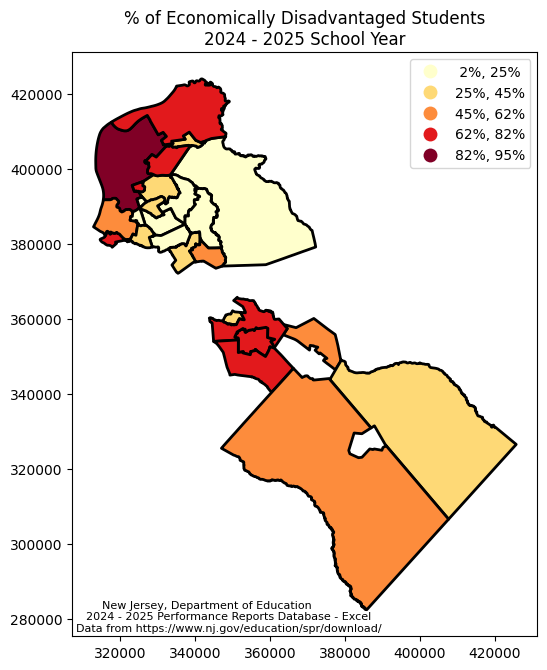

In [17]:
fig, ax = plt.subplots(figsize=(6,8))

# Convert the 'Economically Disadvantaged Students' column to numeric, handling NaN values
a1['Economically Disadvantaged Students'] = a1['Economically Disadvantaged Students'].apply(lambda x: float(x.replace('%', '')) if isinstance(x, str) else x)

a1.plot(ax=ax,figsize=(6,8),column='Economically Disadvantaged Students',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}%"})
ax.set_title('''% of Economically Disadvantaged Students
2024 - 2025 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''New Jersey, Department of Education
            2024 - 2025 Performance Reports Database - Excel
            Data from https://www.nj.gov/education/spr/download/
            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )

In [18]:
DisXls2=DisXls[DisXls['SchoolYear'] =='2023-24'][['CountyName','DistrictCode','DistrictName','Economically Disadvantaged Students']]
DisXls2.rename(columns={'DistrictName' : 'District'}, inplace=True)
DisXls2['District'] = DisXls2['District'].str.upper()
DisXls2

,CountyName,DistrictCode,District,Economically Disadvantaged Students
3,Camden,150,AUDUBON PUBLIC SCHOOL DISTRICT,19.7%
8,Camden,190,BARRINGTON SCHOOL DISTRICT,35.5%
13,Camden,260,BELLMAWR PUBLIC SCHOOL DISTRICT,47.4%
18,Camden,330,BERLIN BOROUGH SCHOOL DISTRICT,17.2%
23,Camden,340,BERLIN TOWNSHIP SCHOOL DISTRICT,36.4%
28,Camden,390,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,34.3%
33,Camden,580,BROOKLAWN PUBLIC SCHOOL DISTRICT,67.3%
38,Camden,680,CAMDEN CITY SCHOOL DISTRICT,54.7%
43,Camden,700,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,50.2%
48,Camden,800,CHERRY HILL SCHOOL DISTRICT,18.1%


In [19]:
njSch['DistrictCode'] = njSch['DistrictCode'].astype(str)
DisXls2['DistrictCode'] = DisXls2['DistrictCode'].astype(str).str.zfill(4) # Ensure 4 digits with leading zeros

njSch_filtered = njSch[njSch['CountyCode'] == '07'].copy() # Use .copy() to avoid SettingWithCopyWarning

a1 = pd.merge(njSch_filtered, DisXls2, left_on='DistrictCode', right_on='DistrictCode', how='outer', indicator=True)
a1

,NJDOE_ID_U,District_x,UNSDLEA,SD_TYPE,GEOID,geometry,CountyCode,DistrictCode,CountyName,District_y,Economically Disadvantaged Students,_merge
0,07-0150,AUDUBON PUBLIC SCHOOL DISTRICT,01050,U,3401050,"POLYGON ((333599.519 389532.256, 334908.018 38...",07,0150,Camden,AUDUBON PUBLIC SCHOOL DISTRICT,19.7%,both
1,07-0190,BARRINGTON SCHOOL DISTRICT,01170,U,3401170,"POLYGON ((341374.86 382055.06, 341383.46 38191...",07,0190,Camden,BARRINGTON SCHOOL DISTRICT,35.5%,both
2,NaN,NaN,NaN,NaN,NaN,None,NaN,0260,Camden,BELLMAWR PUBLIC SCHOOL DISTRICT,47.4%,right_only
3,NaN,NaN,NaN,NaN,NaN,None,NaN,0330,Camden,BERLIN BOROUGH SCHOOL DISTRICT,17.2%,right_only
4,07-0340,BERLIN TOWNSHIP SCHOOL DISTRICT,01620,U,3401620,"POLYGON ((374626.851 357935.944, 375096.547 35...",07,0340,Camden,BERLIN TOWNSHIP SCHOOL DISTRICT,36.4%,both
5,NaN,NaN,NaN,NaN,NaN,None,NaN,0390,Camden,BLACK HORSE PIKE REGIONAL SCHOOL DISTRICT,34.3%,right_only
6,07-0580,BROOKLAWN PUBLIC SCHOOL DISTRICT,02370,U,3402370,"POLYGON ((321421.382 381045.717, 321229.38 381...",07,0580,Camden,BROOKLAWN PUBLIC SCHOOL DISTRICT,67.3%,both
7,07-0680,CAMDEN CITY SCHOOL DISTRICT,02640,U,3402640,"POLYGON ((329538.15 410361.33, 329670.85 41012...",07,0680,Camden,CAMDEN CITY SCHOOL DISTRICT,54.7%,both
8,NaN,NaN,NaN,NaN,NaN,None,NaN,0700,Camden,CAMDEN COUNTY TECHNICAL SCHOOL DISTRICT,50.2%,right_only
9,07-0800,CHERRY HILL SCHOOL DISTRICT,03000,U,3403000,"POLYGON ((347458.19 406942.14, 347464.79 40692...",07,0800,Camden,CHERRY HILL SCHOOL DISTRICT,18.1%,both


In [20]:
a1._merge.value_counts()

,count
_merge,
both,23
right_only,19
left_only,2


<Axes: >

Text(0.5, 1.0, '% of Economically Disadvantaged Students\n2023 - 2024 School Year')

Text(0.35, 0.122, 'New Jersey, Department of Education\n            2024 - 2025 Performance Reports Database - Excel\n            Data from https://www.nj.gov/education/spr/download/\n            ')

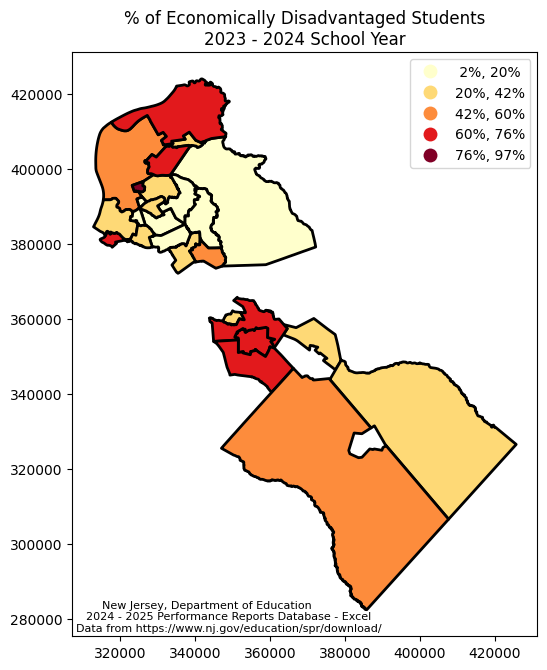

In [21]:
fig, ax = plt.subplots(figsize=(6,8))

# Convert the 'Economically Disadvantaged Students' column to numeric, handling NaN values
a1['Economically Disadvantaged Students'] = a1['Economically Disadvantaged Students'].apply(lambda x: float(x.replace('%', '')) if isinstance(x, str) else x)

a1.plot(ax=ax,figsize=(6,8),column='Economically Disadvantaged Students',legend=True,cmap='YlOrRd',
          scheme='natural_breaks',k=5, edgecolor='black',linewidth=2,legend_kwds= {"fmt": "{:.0f}%"})
ax.set_title('''% of Economically Disadvantaged Students
2023 - 2024 School Year''')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.35, 0.122,
            '''New Jersey, Department of Education
            2024 - 2025 Performance Reports Database - Excel
            Data from https://www.nj.gov/education/spr/download/
            ''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )

In [22]:
njSch['DistrictCode'] = njSch['DistrictCode'].astype(str)
DisXls1['DistrictCode'] = DisXls1['DistrictCode'].astype(str).str.zfill(4) # Ensure 4 digits with leading zeros

njSch_filtered = njSch[njSch['CountyCode'] == '07'].copy() # Use .copy() to avoid SettingWithCopyWarning
njSch_filtered['District'] = njSch_filtered['District'].str.split().str[:2].str.join(' ')

DisXls1['District'] = DisXls1['District'].str.split().str[:2].str.join(' ') # Apply to DisXls1 as well

a1 = pd.merge(njSch_filtered, DisXls1, left_on=['DistrictCode','District'], right_on=['DistrictCode','District'], how='outer', indicator=True)
a1

,NJDOE_ID_U,District,UNSDLEA,SD_TYPE,GEOID,geometry,CountyCode,DistrictCode,CountyName,Economically Disadvantaged Students,_merge
0,07-0150,AUDUBON PUBLIC,01050,U,3401050,"POLYGON ((333599.519 389532.256, 334908.018 38...",07,0150,Camden,24.5%,both
1,07-0190,BARRINGTON SCHOOL,01170,U,3401170,"POLYGON ((341374.86 382055.06, 341383.46 38191...",07,0190,Camden,34.1%,both
2,NaN,BELLMAWR PUBLIC,NaN,NaN,NaN,None,NaN,0260,Camden,57.8%,right_only
3,NaN,BERLIN BOROUGH,NaN,NaN,NaN,None,NaN,0330,Camden,25.2%,right_only
4,07-0340,BERLIN TOWNSHIP,01620,U,3401620,"POLYGON ((374626.851 357935.944, 375096.547 35...",07,0340,Camden,53.3%,both
5,NaN,BLACK HORSE,NaN,NaN,NaN,None,NaN,0390,Camden,44.9%,right_only
6,07-0580,BROOKLAWN PUBLIC,02370,U,3402370,"POLYGON ((321421.382 381045.717, 321229.38 381...",07,0580,Camden,70.7%,both
7,07-0680,CAMDEN CITY,02640,U,3402640,"POLYGON ((329538.15 410361.33, 329670.85 41012...",07,0680,Camden,88.5%,both
8,NaN,CAMDEN COUNTY,NaN,NaN,NaN,None,NaN,0700,Camden,56.1%,right_only
9,07-0800,CHERRY HILL,03000,U,3403000,"POLYGON ((347458.19 406942.14, 347464.79 40692...",07,0800,Camden,23.2%,both


In [23]:
a1._merge.value_counts()

,count
_merge,
both,22
right_only,20
left_only,3


In [24]:
#I thought this was neat showing bar graph of just right :-), Gemini assisted
import seaborn as sns
import matplotlib.pyplot as plt

# Sort the DataFrame by 'Economically Disadvantaged Students' for better visualization
a1_right_only_sorted = a1_right_only.sort_values(by='Economically Disadvantaged Students', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='Economically Disadvantaged Students', y='District', data=a1_right_only_sorted, palette='viridis', ax=ax)
ax.set_title('% of Economically Disadvantaged Students (Right Only)\n2024 - 2025 School Year')
ax.set_xlabel('Economically Disadvantaged Students (%)')
ax.set_ylabel('District')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

NameError: name 'a1_right_only' is not defined